In [1]:
import numpy as np
import pandas as pd
rng = np.random.default_rng(12345)

from lymph.models import Unilateral
from lymixture import LymphMixture
from lymixture.utils import binom_pmf, late_binomial, normalize
from fixtures import get_patient_data
PARAMS_C1 = {
    "TtoII_spread": 0.05,
    "TtoIII_spread": 0.25,
    "IItoIII_spread": 0.5,
    "late_p": 0.5,
}
PARAMS_C2 = {
    "TtoII_spread": 0.25,
    "TtoIII_spread": 0.05,
    "IItoIII_spread": 0.1,
    "late_p": 0.5,
}

In [2]:
# data = pd.read_csv("data/mixture.csv", header=[0,1,2])
# new_column = pd.MultiIndex.from_tuples([('diagnose', 'ipsi', ['II', 'III'])])

# Initialize the new column with None values
# data['diagnose', 'ipsi', 'II'] = None
# data['diagnose', 'ipsi', 'III'] = None

# data


In [2]:
graph = {
    ("tumor", "T"): ["II", "III"],
    ("lnl", "II"): ["III"],
    ("lnl", "III"): [],
}
num_components = 2

mixture = LymphMixture(
    model_cls=Unilateral,
    model_kwargs={"graph_dict": graph},
    num_components=num_components,
    universal_p= False
)

mixture.set_distribution("early", binom_pmf(np.arange(11), 10, 0.3))
mixture.set_distribution("late", late_binomial)
mixture.get_all_distributions()

PARAMS_C1 = {
    "0_TtoII_spread": 0.05,
    "0_TtoIII_spread": 0.25,
    "0_IItoIII_spread": 0.5,
    "0_late_p": 0.5,
}
PARAMS_C2 = {
    "1_TtoII_spread": 0.25,
    "1_TtoIII_spread": 0.05,
    "1_IItoIII_spread": 0.1,
    "1_late_p": 0.5,
}
mixture.set_params(**PARAMS_C1)
mixture.set_params(**PARAMS_C2)


# mixture.load_patient_data(
#     data,
#     split_by=("tumor", "1", "subsite"),
#     mapping=lambda x: x,
# )

# mixture.set_modality("path", 1., 1.)
# mixture.set_modality("diagnose", 1., 0.81 )
mixture.components[0].set_modality("path", 1., 1.)
mixture.components[1].set_modality("path", 1., 1.)


In [4]:
num_s1 = 350
num_s2 = 200
num_s3 = 450
tstage_ratio = 0.5
mix1 = 0.2
mix2 = 0.5
mix3 = 0.9
mixture.set_params(**PARAMS_C1)
c1_data = mixture.components[0].draw_patients(
    num=int(np.round(num_s1*mix1)) + int(np.round(num_s2 * mix2)) + int(np.round(num_s3 * mix3)),
    stage_dist=[tstage_ratio, 1 - tstage_ratio],
    rng=rng,
)
# for index, patient in c1_data.iterrows():
#     staging = patient["tumor", "1", "t_stage"]
#     involvement = mixture.components[0].draw_diagnosis(
#         list(mixture.get_all_distributions()[staging].draw_diag_times(1))
#     )
#     c1_data.loc[index, ('path', 'ipsi', 'II')] = involvement[0]
#     c1_data.loc[index, ('path', 'ipsi', 'III')] = involvement[1]
mixture.set_params(**PARAMS_C2)
c2_data = mixture.components[1].draw_patients(
    num=int(np.round(num_s1*(1-mix1))) + int(np.round(num_s2 * (1-mix2))) + int(np.round(num_s3 * (1-mix3))),
    stage_dist=[tstage_ratio, 1 - tstage_ratio],
    rng=rng,
)
# for index, patient in enumerate(c2_data):
#     staging = patient["tumor", "1", "stage"]
#     involvement = mixture.components[1].draw_diagnosis(mixture.get_all_distributions()[staging].draw_diag_times(1))
#     c2_data['path','ipsi','II'] = involvement[0]
#     c2_data['path','ipsi','III'] = involvement[1]

s1_data = pd.concat([c1_data.iloc[:int(np.round(num_s1*mix1))], c2_data.iloc[:int(np.round(num_s1*(1-mix1)))]]).reset_index(drop=True)
s2_data = pd.concat([c1_data.iloc[int(np.round(num_s1*mix1)):int(np.round(num_s1*mix1))+int(np.round(num_s2*mix2))], c2_data.iloc[int(np.round(num_s1*(1-mix1))):int(np.round(num_s1*(1-mix1)))+int(np.round(num_s2*(1-mix2)))]]).reset_index(drop=True)
s3_data = pd.concat([c1_data.iloc[int(np.round(num_s1*mix1))+int(np.round(num_s2*mix2)):], c2_data.iloc[int(np.round(num_s1*(1-mix1)))+int(np.round(num_s2*(1-mix2))):]]).reset_index(drop=True)
s1_data['tumor','1','subsite'] = "s1"
s2_data['tumor','1','subsite']  = "s2"
s3_data['tumor','1','subsite']  = "s3"

data = pd.concat([s1_data, s2_data, s3_data], ignore_index=True, axis=0)

In [5]:
data.loc[data['tumor','1','subsite'] == 's1']['path','ipsi'].sum()/350

II     0.517143
III    0.400000
dtype: float64

In [6]:
data.loc[data['tumor','1','subsite'] == 's2']['path','ipsi'].sum()/200

II     0.405
III    0.470
dtype: float64

In [7]:
data.loc[data['tumor','1','subsite'] == 's3']['path','ipsi'].sum()/450

II     0.195556
III    0.655556
dtype: float64

Set the diagnostic modality to be the same as in the generated dataset.

In [8]:
mixture.load_patient_data(
    data,
    split_by=("tumor", "1", "subsite"),
    mapping=lambda x: x,
)

mixture.set_modality("path", 1., 1.)
# mixture.set_modality("diagnose", 1., 0.81 )

Initialize random model parameters and latent variables/responsibilities.

In [9]:
from lymixture.em import expectation, maximization, maximization_component_wise

params = {k: rng.uniform() for k in mixture.get_params()}
mixture.set_params(**params)
mixture.normalize_mixture_coefs()
latent = normalize(rng.uniform(size=mixture.get_resps().shape).T, axis=0).T

In [10]:
def to_numpy(params: dict[str, float]) -> np.ndarray:
    return np.array([p for p in params.values()])

In [11]:
def check_convergence(params_history, likelihood_history, steps_back_list):
    current_params = params_history[-1]
    current_likelihood = likelihood_history[-1]
    for steps_back in steps_back_list:
        previous_params = params_history[-steps_back - 1]
        if np.allclose(to_numpy(current_params), to_numpy(previous_params)):
            print('stopped due to parameter similarity')
            return True  # Return True if any of the steps is close
        elif (np.isclose(current_likelihood, likelihood_history[-steps_back - 1],rtol = 0, atol = 0.01)) and np.all(current_likelihood >= np.array(likelihood_history)):
            print('stopped due to likelihood similarity')
            return True
    return False

Iterate the computation of the expectation value of the latent variables (E-step) and the maximization of the (complete) data log-likelihood w.r.t. the model parameters (M-step).

In [12]:
is_converged = False
count = 0
params_history = []
likelihood_history = []
params_history.append(params.copy())
likelihood_history.append(mixture.likelihood(use_complete = False))
# Number of steps to look back for convergence
look_back_steps = 3

while not is_converged:
    print(count)
    print(likelihood_history[-1])
    old_params = params
    latent = expectation(mixture, params)
    params = maximization(mixture, latent)

    # Append current params and likelihood to history
    params_history.append(params.copy())
    likelihood_history.append(mixture.likelihood(use_complete=False))
    
    # Check if converged
    if count >= 3:  # Ensure enough history is available
        is_converged = check_convergence(params_history, likelihood_history,list(range(1,look_back_steps+1)))
    count += 1

0
-3963.9647467605064
1
-1278.8524962406755
2
-1247.9658061422
3
-1235.1103186916066
4
-1229.1241615744375
5
-1226.2890324523771
6
-1225.0360940006008
7
-1224.492690105567
8
-1224.3065525341185
9
-1224.1979341105955
10
-1224.122960766707
11
-1224.064653511658
12
-1224.0170812991812
13
-1223.9769959549544
14
-1223.9425726996512
15
-1223.9129531449064
16
-1223.8867284269077
17
-1223.8628272667045
18
-1223.8414233533701
19
-1223.8210533892916
20
-1223.8023794342607
21
-1223.7838209198808
22
-1223.766420283031
23
-1223.7490420191923
24
-1223.7314209092488
25
-1223.7144792570255
26
-1223.697539456729
27
-1223.6805603208882
28
-1223.6632890776132
29
-1223.6463898295274
30
-1223.6293057566186
31
-1223.6117520869934
32
-1223.5946264749437
33
-1223.577017748476
34
-1223.5594164151396
35
-1223.5417124142764
36
-1223.524133675102
37
-1223.5064995864611
38
-1223.4886731576748
39
-1223.4707018212816
40
-1223.4532017482343
41
-1223.4356095829328
42
-1223.4179541163628
43
-1223.4002570419834
44
-1223

Faster version with component-wise-maximization

In [158]:
is_converged = False
count = 0
params_history = []
likelihood_history = []
params_history.append(params.copy())
likelihood_history.append(mixture.likelihood(use_complete = False))
# Number of steps to look back for convergence
look_back_steps = 3

while not is_converged:
    print(count)
    print(likelihood_history[-1])

    old_params = params
    latent = expectation(mixture, params)
    params = maximization_component_wise(mixture, latent)

    # Append current params and likelihood to history
    params_history.append(params.copy())
    likelihood_history.append(mixture.likelihood(use_complete=False))
    
    # Check if converged
    if count >= 3:  # Ensure enough history is available
        is_converged = check_convergence(params_history, likelihood_history,list(range(1,look_back_steps+1)))
    count += 1

0
-1223.9508479604065
1
-1222.4335406950113
2
-1222.424723605693
3
-1222.416032681288
stopped due to likelihood similarity


In [33]:
mixture.get_params(as_dict =True)

{'0_TtoII_spread': 0.04127163400501063,
 '0_TtoIII_spread': 0.2709495285494925,
 '0_IItoIII_spread': 0.9999430551318891,
 '0_late_p': 0.5055337613774329,
 '0_s1_coef': 0.18259649526742802,
 '0_s2_coef': 0.44208830608440924,
 '0_s3_coef': 0.9066188891194431,
 '1_TtoII_spread': 0.2097400143687136,
 '1_TtoIII_spread': 0.0756524019601312,
 '1_IItoIII_spread': 0.034867198319635945,
 '1_late_p': 0.595091224016528,
 '1_s1_coef': 0.8174035047325721,
 '1_s2_coef': 0.5579116939155907,
 '1_s3_coef': 0.093381110880557}

## Compare to producing parameters

In [30]:
mixture.set_params(**PARAMS_C1)
mixture.set_params(**PARAMS_C2)
mixture.set_params(**{'0_s1_coef':mix1,
                    '0_s2_coef':mix2,
                    '0_s3_coef':mix3,
                    '1_s1_coef':1-mix1,
                    '1_s2_coef':1-mix2,
                    '1_s3_coef':1-mix3})
mixture.get_params(as_dict =True)


{'0_TtoII_spread': 0.05,
 '0_TtoIII_spread': 0.25,
 '0_IItoIII_spread': 0.5,
 '0_late_p': 0.5,
 '0_s1_coef': 0.2,
 '0_s2_coef': 0.5,
 '0_s3_coef': 0.9,
 '1_TtoII_spread': 0.25,
 '1_TtoIII_spread': 0.05,
 '1_IItoIII_spread': 0.1,
 '1_late_p': 0.5,
 '1_s1_coef': 0.8,
 '1_s2_coef': 0.5,
 '1_s3_coef': 0.09999999999999998}

In [159]:
mixture.likelihood(use_complete=True)

-1539.7103504262643

In [160]:
mixture.likelihood(use_complete=False)

-1222.4074786238189

## Prevalence analysis

In [41]:
mixture.risk('s1',involvement = {'II':True}, t_stage = 'late')

0.6366204614487254

In [42]:
data.loc[(data['tumor','1','subsite'] == 's1') & (data['tumor','1','t_stage'] == 'late')]['path'].sum() / len(data.loc[(data['tumor','1','subsite'] == 's1') & (data['tumor','1','t_stage'] == 'late')])


ipsi  II     0.682635
      III    0.467066
dtype: float64

## Sample model parameters

In [38]:
original_latent = mixture.get_resps()
original_params = mixture.get_params(as_dict=True)

In [16]:
def sample_latent(df):
    sampled_df = pd.DataFrame(0, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    for index, row in df.iterrows():
        sampled_index = np.random.choice(df.columns, p=row)  # Sample based on the probabilities in the row
        sampled_df.at[index, sampled_index] = 1  # Set the sampled column to 1
    return sampled_df

In [21]:
latent = sample_latent(original_latent)

In [200]:
import emcee
from multiprocessing import Pool

def log_prob_fn2(theta, model):
    lower_bounds = np.zeros(len(theta))
    upper_bounds = np.ones(len(theta)) 

    # Check if the parameters are within bounds
    if np.any(theta < lower_bounds) or np.any(theta > upper_bounds):
        return -np.inf  # Return -infinity if out of bounds
    model.set_params(*theta)
    return model.likelihood(log=True, use_complete = True)

def sample_model_params_continue_chain(model, steps = 10, chain = None, latent = None):
    if latent is None:
        latent = model.get_resps()
    model.set_resps(latent)
    model.set_mixture_coefs(model.compute_mixture())
    current_params = list(model.get_params(as_dict = False))
    ndim = len(current_params)
    nwalkers = 5 * ndim
    if chain is None:
        ndim = len(current_params)
        nwalkers = 5 * ndim
        perturbation = 1e-4 * abs(np.random.randn(nwalkers, ndim))
        starting_points = np.ones((nwalkers, ndim)) * current_params + perturbation
        starting_points[starting_points > 1] = 1 - perturbation[starting_points > 1]
    else:
        starting_points = chain
    with Pool() as pool:
        original_sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_prob_fn2,
            args=(model,),
            pool=pool,
        )
        original_sampler.run_mcmc(initial_state=starting_points, nsteps=steps, progress=False)
    ar = np.mean(original_sampler.acceptance_fraction)
    print(f"Mean acceptance rate: {ar * 100 :.2f}%")
    return original_sampler.get_chain(discard=0, thin=1, flat=False)

In [58]:
all_samples = []

In [59]:
IP_rounds = 20000
n_steps = 1
n_dim = len(mixture.get_params())
n_walkers = 5 * n_dim
params_samples = []
latent_samples = []
complete_likelihoods = []
incomplete_likelihoods = []
latent = sample_latent(original_latent)
chain = None
for round in range(IP_rounds):
    samples = sample_model_params_continue_chain(model = mixture, steps = n_steps, chain = chain, latent = latent)
    chain = samples[-1]
    samples_flat = samples.reshape(n_steps * n_walkers, n_dim)
    latent_samples.append(latent)
    params_samples.append(samples_flat[-1])
    mixture.set_params(*samples_flat[-1])
    latent_exp = expectation(mixture, mixture.get_params())
    all_samples.append(samples_flat)
    complete_likelihoods.append(mixture.likelihood(use_complete=True))
    incomplete_likelihoods.append(mixture.likelihood(use_complete=False))
    latent = sample_latent(pd.DataFrame(latent_exp))
    print('latent difference = ',abs((latent - latent_samples[-1]).sum()).sum()/2)
    print(round, 'th run with complete likelihood', complete_likelihoods[-1], ' and incomplete likelihood', incomplete_likelihoods[-1])

Mean acceptance rate: 71.43%
latent difference =  47.0
0 th run with complete likelihood -3506.282073987902  and incomplete likelihood -2663.9326532238483
Mean acceptance rate: 57.14%
latent difference =  20.0
1 th run with complete likelihood -3580.132908865289  and incomplete likelihood -2663.7857168699948
Mean acceptance rate: 47.14%
latent difference =  3.0
2 th run with complete likelihood -3589.53162751749  and incomplete likelihood -2663.675396817027
Mean acceptance rate: 67.14%
latent difference =  13.0
3 th run with complete likelihood -3580.4685308879516  and incomplete likelihood -2663.5620903152158
Mean acceptance rate: 65.71%
latent difference =  6.0
4 th run with complete likelihood -3591.607870377033  and incomplete likelihood -2663.1322697382084
Mean acceptance rate: 57.14%
latent difference =  23.0
5 th run with complete likelihood -3544.4373161890917  and incomplete likelihood -2663.1322697382084
Mean acceptance rate: 67.14%
latent difference =  4.0
6 th run with comp

In [33]:
import matplotlib.pyplot as plt

(array([ 689., 2174., 2037., 2281., 2726., 1832., 4523., 3084.,  472.,
         182.]),
 array([0.0279288 , 0.03605673, 0.04418466, 0.05231258, 0.06044051,
        0.06856844, 0.07669637, 0.08482429, 0.09295222, 0.10108015,
        0.10920808]),
 <BarContainer object of 10 artists>)

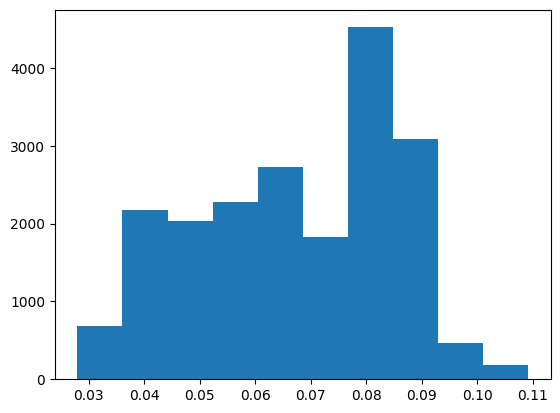

In [60]:
plt.hist(np.array(params_samples)[:,0])

(array([  75.,  877., 2826., 3086., 2059., 2698., 3981., 3130., 1160.,
         108.]),
 array([-3672.42320354, -3632.15824484, -3591.89328614, -3551.62832744,
        -3511.36336873, -3471.09841003, -3430.83345133, -3390.56849263,
        -3350.30353393, -3310.03857523, -3269.77361652]),
 <BarContainer object of 10 artists>)

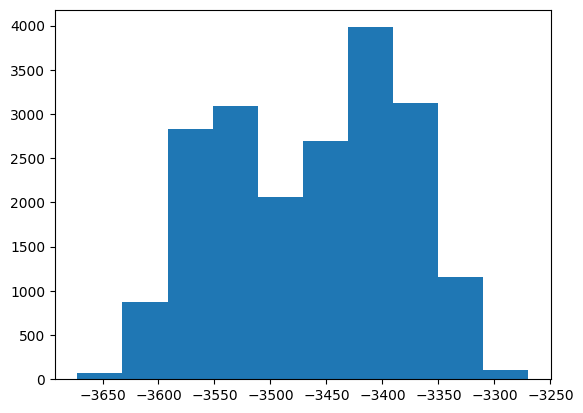

In [61]:
plt.hist(complete_likelihoods)

In [62]:
latenter_diff = []
for i in range(1, len(latent_samples)):
    latenter_diff.append(abs((latent_samples[i-1]-latent_samples[i])).sum().sum()/2)

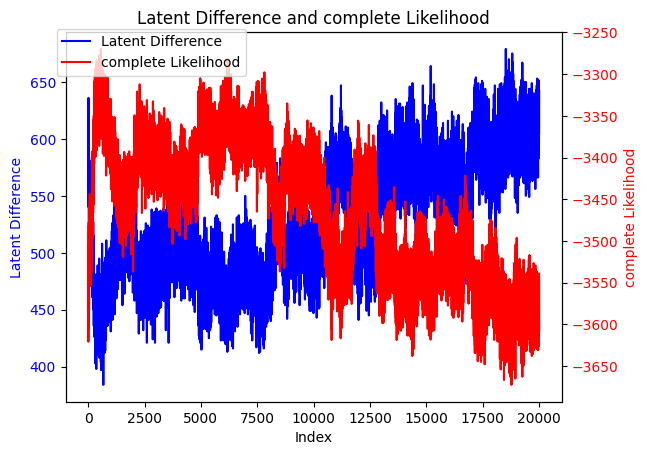

In [64]:
fig, ax1 = plt.subplots()

# Plot the first dataset (latenter_diff) on the primary y-axis
ax1.plot(latenter_diff, label='Latent Difference', color='blue')
ax1.set_xlabel('Index')
ax1.set_ylabel('Latent Difference', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Create the secondary y-axis
ax2 = ax1.twinx()

# Plot the second dataset (complete_likelihoods) on the secondary y-axis
ax2.plot(complete_likelihoods, label='complete Likelihood', color='red')
ax2.set_ylabel('complete Likelihood', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Show the legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Display the plot
plt.title("Latent Difference and complete Likelihood")
plt.show()

Text(0.5, 0, 'Iteration')

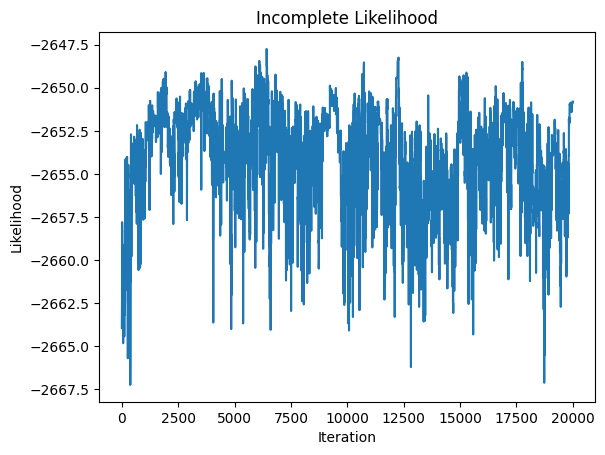

In [65]:
plt.plot(incomplete_likelihoods)
plt.title("Incomplete Likelihood")
plt.ylabel("Likelihood")
plt.xlabel("Iteration")



In [66]:
involvement_II = {'II': True}
involvement_III = {'III': True}
component_list = list(range(len(mixture.components)))
component_dictionary_early = {}


In [67]:
for component in component_list:
    risk_dictionary = {

        'II': [],
        'III': [],
    }
    for sample in params_samples:
        mixture.set_params(*sample)
        risk_dictionary['II'].append(mixture.components[component].risk(involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.components[component].risk(involvement = involvement_III, t_stage = 'early'))
    component_dictionary_early[str(component)] = risk_dictionary

In [101]:
from cycler import cycler
def multiple_plotter_component(risk_dictionary, component, stage = ''):
    COLORS = {
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        risks[key] = np.array(risk_dictionary[key])*100
    
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), hist_cycl)
    for vals, label, hstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for component {component}",fontsize = 16)
    

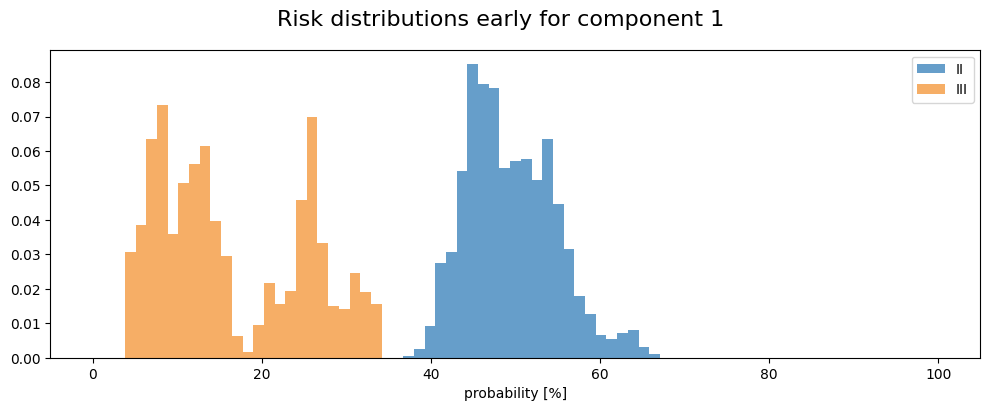

In [102]:
multiple_plotter_component(component_dictionary_early['1'], '1', 'early')

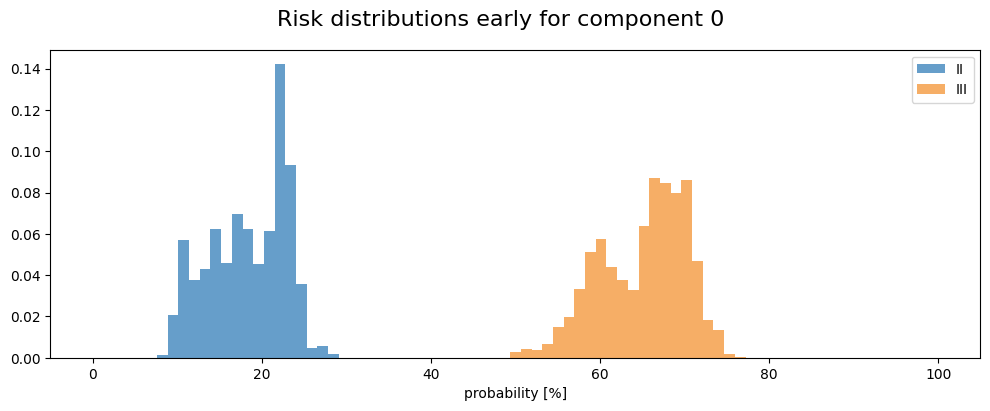

In [103]:
multiple_plotter_component(component_dictionary_early['0'], '0', 'early')

In [88]:
PARAMS_C2

{'1_TtoII_spread': 0.25,
 '1_TtoIII_spread': 0.05,
 '1_IItoIII_spread': 0.1,
 '1_late_p': 0.5}

In [89]:
PARAMS_C1

{'0_TtoII_spread': 0.05,
 '0_TtoIII_spread': 0.25,
 '0_IItoIII_spread': 0.5,
 '0_late_p': 0.5}

In [71]:
from cycler import cycler
import scipy as sp
def multiple_plotter(dataset, risk_dictionary, subsite, stage = ''):
    COLORS = {"green": '#00afa5',
        "blue": '#005ea8',
        "orange": '#f17900',
        "red": '#ae0060',
        "gray": '#c5d5db',
    }
    hist_cycl = (
        cycler(histtype=["stepfilled", "step"])
        * cycler(color=list(COLORS.values()))
    )
    line_cycl = (
        cycler(linestyle=["-", "--"])
        * cycler(color=list(COLORS.values()))
    )
    if stage == 'early' or stage == 'late':
        data_selected = dataset.loc[(dataset['tumor']['1']['subsite'] == subsite) & (dataset['tumor']['1']['t_stage'] == stage)]  
    else:
        data_selected = dataset.loc[dataset['tumor']['1']['subsite'] == subsite]
    min_value = 0
    max_value = 100
    prevalence = {}
    number_of_patients = {}
    risks = {}
    for key in risk_dictionary.keys():
        prevalence[key] = (data_selected['path']['ipsi'][key] == True).sum()
        number_of_patients[key] = len(data_selected)
        risks[key] = np.array(risk_dictionary[key])*100
    
    num_matches = [prevalence[key] for key in risk_dictionary.keys()]
    num_totals = [number_of_patients[key] for key in risk_dictionary.keys()]
    values = [risks[key] for key in risk_dictionary.keys()]
    hist_kwargs = {
                "bins": np.linspace(min_value, max_value, 80),
                "density": True,
                "alpha": 0.6,
                "linewidth": 2.,
            }
    fig, ax = plt.subplots(figsize=(12,4))

    x = np.linspace(min_value, max_value, 200)
    zipper = zip(values, risk_dictionary.keys(), num_matches, num_totals, hist_cycl, line_cycl)
    for vals, label, a, n, hstyle, lstyle in zipper:
        ax.hist(
            vals,
            label=label,
            **hist_kwargs,
            **hstyle
        )
        if not np.isnan(a):
            post = sp.stats.beta.pdf(x / 100., a+1, n-a+1) / 100.
            ax.plot(x, post, label=f"{int(a)}/{int(n)}", **lstyle)
        ax.legend()
        ax.set_xlabel("probability [%]")
    plt.suptitle(f"Risk distributions {stage} for subsite {subsite}",fontsize = 16)
    

In [72]:
subsite_dictionary_early = {}
subsite_list = list(mixture.subgroups.keys())

In [73]:
for subsite in subsite_list:
    # subsite = 'C02'
    risk_dictionary = {
        'II': [],
        'III': [],
    }
    for sample in params_samples:
        mixture.set_params(*sample)
        risk_dictionary['II'].append(mixture.risk(subgroup = subsite, involvement = involvement_II, t_stage = 'early'))
        risk_dictionary['III'].append(mixture.risk(subgroup = subsite, involvement = involvement_III, t_stage = 'early'))
        if len(risk_dictionary['II'])%1000 == 0:
            print('1k done')
    subsite_dictionary_early[subsite] = risk_dictionary

1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done
1k done


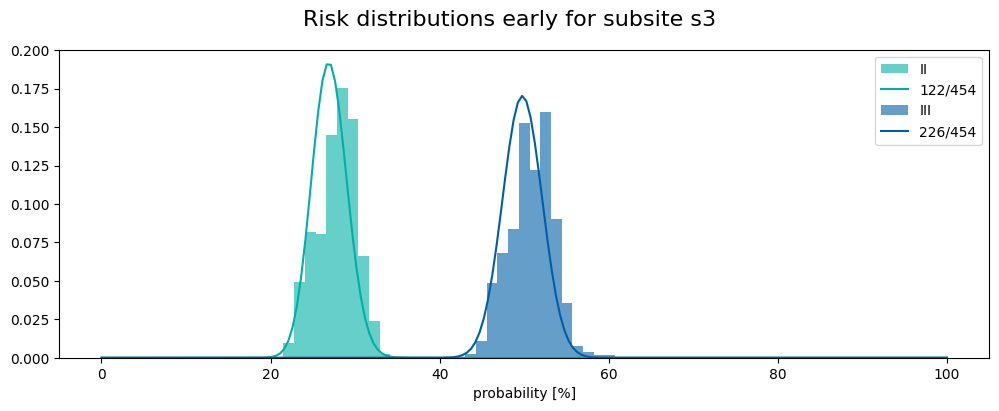

In [106]:
multiple_plotter(mixture.patient_data, risk_dictionary = subsite_dictionary_early['s3'], subsite = 's3', stage = 'early')

In [75]:
mixture.get_params()

{'0_TtoII_spread': 0.07145111889627813,
 '0_TtoIII_spread': 0.3418649876264113,
 '0_IItoIII_spread': 0.01817937487354271,
 '0_late_p': 0.4353352790574156,
 '0_s1_coef': 0.22702744815414602,
 '0_s2_coef': 0.1821788456240946,
 '0_s3_coef': 0.654125527449027,
 '1_TtoII_spread': 0.1807921605477321,
 '1_TtoIII_spread': 0.09075364564165285,
 '1_IItoIII_spread': 0.019272196275826797,
 '1_late_p': 0.4888512080686064,
 '1_s1_coef': 0.772972551845854,
 '1_s2_coef': 0.8178211543759054,
 '1_s3_coef': 0.3458744725509731}

In [79]:
mixture.risk('s2',involvement = {'III':True})

0.32447894415572676

In [80]:
data.loc[(data['tumor','1','subsite'] == 's3') & (data['tumor','1','t_stage'] == 'early')]['path'].sum() / len(data.loc[(data['tumor','1','subsite'] == 's3') & (data['tumor','1','t_stage'] == 'early')])


ipsi  II     0.268722
      III    0.497797
dtype: float64

## Markov chain latent sampling

In [302]:
from lymixture.utils import map_to_simplex, map_to_unit_cube
import emcee
from multiprocessing import Pool
mixture.set_params(**original_params)
mixture.set_resps(original_latent)

In [45]:
def log_prob_fn2(theta, model):
    lower_bounds = np.zeros(len(theta))
    upper_bounds = np.ones(len(theta)) 

    # Check if the parameters are within bounds
    if np.any(theta < lower_bounds) or np.any(theta > upper_bounds):
        return -np.inf  # Return -infinity if out of bounds
    model.set_params(*theta)
    return model.likelihood(log=True, use_complete = True)

def sample_model_params_continue_chain(model, steps = 1, chain = None, latent = None):
    if latent is None:
        latent = model.get_resps()
    model.set_resps(latent)
    model.set_mixture_coefs(model.compute_mixture())
    current_params = list(model.get_params(as_dict = False))
    ndim = len(current_params)
    nwalkers = 5 * ndim
    if chain is None:
        ndim = len(current_params)
        nwalkers = 5 * ndim
        perturbation = 1e-4 * abs(np.random.randn(nwalkers, ndim))
        starting_points = np.ones((nwalkers, ndim)) * current_params + perturbation
        starting_points[starting_points > 1] = 1 - perturbation[starting_points > 1]
    else:
        starting_points = chain
    with Pool() as pool:
        original_sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_prob_fn2,
            args=(model,),
            pool=pool,
        )
        original_sampler.run_mcmc(initial_state=starting_points, nsteps=steps, progress=False)
    ar = np.mean(original_sampler.acceptance_fraction)
    print(f"Mean acceptance rate: {ar * 100 :.2f}%")
    return original_sampler.get_chain(discard=0, thin=1, flat=False)

In [296]:
mixture.likelihood(use_complete = True)

-1539.6562741024334

In [300]:
mixture.get_resps()

,0,1
0,0.610384,0.389616
1,0.888865,0.111135
2,0.888865,0.111135
3,0.610384,0.389616
4,0.550276,0.449724
...,...,...
995,0.914673,0.085327
996,0.014565,0.985435
997,0.697547,0.302453
998,0.843741,0.156259


In [954]:
def complete_latent_likelihood_direct(theta, model):
    df = model.get_resps()
    sampled_df = pd.DataFrame(theta, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    model.set_resps(sampled_df)
    return model.likelihood(log=True, use_complete = True)

def mh_sampler_batch(model, log_prob_fn, batch_percentage = 0.1):
    """
    A basic Metropolis-Hastings sampler for latent variables
    """
    current_position = model.get_resps()
    new_position = current_position.copy()
    current_log_prob = log_prob_fn(current_position,model)
    n_dim = len(current_position)
    batch_size = rng.integers(1, n_dim*batch_percentage)
    swapped_indices = rng.choice(n_dim, size=batch_size, replace=False)
    new_position.iloc[swapped_indices, [0, 1]] = new_position.iloc[swapped_indices, [1, 0]].to_numpy()
    new_log_prob = log_prob_fn(new_position,model)
    accept_ratio = np.exp(new_log_prob - current_log_prob)
    print(batch_size)
    print(accept_ratio)
    if np.random.rand() < accept_ratio:
        print('accepted with ', batch_size, 'swaps')
        print('difference in likelihood = ', new_log_prob - current_log_prob)
        return new_position, new_log_prob
    model.set_resps(current_position)
    return current_position, current_log_prob

def mh_sampler_per_patient(model, log_prob_fn):
    """
    A basic Metropolis-Hastings sampler for latent variables
    """
    current_position = model.get_resps()
    new_position = current_position.copy()
    accepted_position = current_position.copy()
    current_log_prob = log_prob_fn(current_position,model)
    new_position.iloc[:, [0, 1]] = current_position.iloc[:, [1, 0]].to_numpy()
    
    current_assignments = np.argmax(np.array(current_position), axis=1)
    new_assignments = np.argmax(np.array(new_position), axis=1)

    log_acceptance_ratio = (model.patient_mixture_likelihoods(log = True)[np.arange(len(new_assignments)),new_assignments] - model.patient_mixture_likelihoods(log = True)[np.arange(len(current_assignments)),current_assignments])/0.2
    accept_ratio = np.exp(log_acceptance_ratio)
    accept_thresholds = np.random.rand(len(accept_ratio))
    accepted_indices = np.where(accept_thresholds < accept_ratio)[0]
    accepted_position.iloc[accepted_indices, [0, 1]] = current_position.iloc[accepted_indices, [1, 0]].to_numpy()
    model.set_resps(accepted_position)
    new_log_prob = log_prob_fn(accepted_position,model)
    print(len(accepted_indices), 'swaps accepted')
    # print('difference in likelihood = ', current_log_prob - new_log_prob)
    # print('new likelihood = ', new_log_prob)
    return current_position, current_log_prob

In [949]:
mixture.set_params(**original_params)
mixture.set_resps(original_latent)
resps = mixture.get_resps()
resps[:] = (resps.values == resps.values.max(axis=1, keepdims=True)).astype(int) # Set the assignments to hard assignments
mixture.set_resps(resps)

In [939]:
mixture.likelihood()

-1378.5192715338858

In [948]:
current_pos, current_prob = mh_sampler_per_patient(mixture, complete_latent_likelihood_direct)

46 swaps accepted
difference in likelihood =  13.285098265283295
new likelihood =  -1391.804369799169


In [846]:
mixture.likelihood(use_complete = True)

-1378.5192715338858

In [942]:
samples = []
probs = []
for i in range(1000):
    current_pos, current_prob = mh_sampler_per_patient(mixture, complete_latent_likelihood_direct)
    samples.append(current_pos)
    probs.append(current_prob)

42 swaps accepted
difference in likelihood =  9.449800483588433
new likelihood =  -1387.9690720174742
59 swaps accepted
difference in likelihood =  -5.143228682127074
new likelihood =  -1382.8258433353471
52 swaps accepted
difference in likelihood =  4.231974297131956
new likelihood =  -1387.057817632479
56 swaps accepted
difference in likelihood =  -2.2443706348751675
new likelihood =  -1384.813446997604
61 swaps accepted
difference in likelihood =  3.865022090311868
new likelihood =  -1388.6784690879158
66 swaps accepted
difference in likelihood =  -3.729630195502523
new likelihood =  -1384.9488388924133
50 swaps accepted
difference in likelihood =  -0.22479913239976668
new likelihood =  -1384.7240397600135
51 swaps accepted
difference in likelihood =  1.0222696960292978
new likelihood =  -1385.7463094560428
53 swaps accepted
difference in likelihood =  -0.5486402952330991
new likelihood =  -1385.1976691608097
55 swaps accepted
difference in likelihood =  0.6647997010736617
new likel

In [943]:
total = samples[0]
for i in samples[1:]:
    total = total + i

In [944]:
((total/1000)[0] - original_latent[0])

0      0.284616
1     -0.111135
2     -0.111135
3      0.282616
4      0.153724
         ...   
995    0.085327
996    0.014565
997   -0.287453
998    0.156259
999    0.116864
Name: 0, Length: 1000, dtype: float64

(array([  2.,  20.,  66., 184., 329., 292.,  96.,  10.,   0.,   1.]),
 array([-1391.04886573, -1389.79590631, -1388.54294689, -1387.28998747,
        -1386.03702805, -1384.78406863, -1383.53110921, -1382.27814979,
        -1381.02519037, -1379.77223095, -1378.51927153]),
 <BarContainer object of 10 artists>)

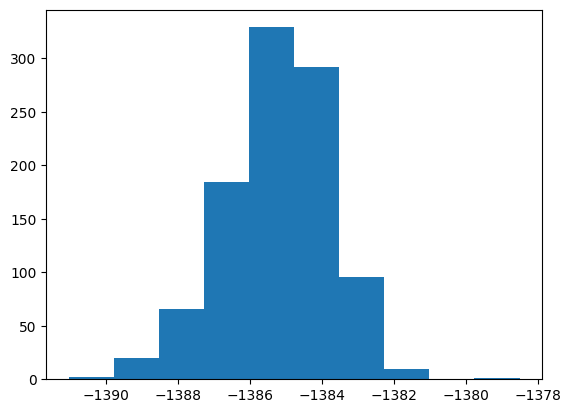

In [946]:
import matplotlib.pyplot as plt
plt.hist(probs)

In [936]:
(total/1000)[0]

0      0.903
1      0.000
2      0.000
3      0.899
4      0.733
       ...  
995    1.000
996    1.000
997    0.014
998    1.000
999    1.000
Name: 0, Length: 1000, dtype: float64

In [64]:
def init_latent_sampler(model,steps_latent = 1):
    backend = emcee.backends.HDFBackend("../../latent_samples.hdf5")
    current_resps = np.array(model.get_resps())
    unit_cube_resps = map_to_unit_cube(current_resps.T).T
    n_dim_latent = np.shape(unit_cube_resps)[0]
    n_walkers_latent = 1
    perturbation = np.random.randn(n_walkers_latent, n_dim_latent)
    starting_points_latent = np.ones((n_walkers_latent, n_dim_latent)) * unit_cube_resps.reshape(len(unit_cube_resps)) + perturbation
    print(starting_points_latent)
    backend.reset(n_walkers_latent, n_dim_latent)
    with Pool() as pool:
        latent_sampler = emcee.EnsembleSampler(
            n_walkers_latent, n_dim_latent, complete_latent_likelihood,
            args=(model,),
            pool=pool, backend = backend, moves = emcee.moves.GaussianMove(cov = 0.1,mode = "vector")
        )
        state = latent_sampler.run_mcmc(initial_state=starting_points_latent, nsteps=steps_latent, progress=False)
    return latent_sampler, state

In [950]:
def init_params_sampler(model,steps_params = 1):
    backend = emcee.backends.HDFBackend("../../params_samples.hdf5")
    current_params = list(model.get_params(as_dict = False))
    ndim = len(current_params)
    nwalkers = 5 * ndim
    ndim = len(current_params)
    nwalkers = 5 * ndim
    perturbation = 1e-2 * abs(np.random.randn(nwalkers, ndim))
    starting_points = np.ones((nwalkers, ndim)) * current_params + perturbation
    starting_points[starting_points > 1] = 1 - perturbation[starting_points > 1]
    backend.reset(nwalkers, ndim)
    with Pool() as pool:
        original_sampler = emcee.EnsembleSampler(
            nwalkers, ndim, log_prob_fn2,
            args=(model,),
            pool=pool, backend = backend
        )
        state = original_sampler.run_mcmc(initial_state=starting_points, nsteps=steps_params, progress=True)
    return original_sampler, state

In [53]:
mixture.set_resps(original_latent)
mixture.set_params(**original_params)

()

In [407]:
IP_rounds = 100
n_steps_params = 30
n_steps_latent = 1
n_dim_params = len(mixture.get_params())
n_walkers_params = 5 * n_dim_params
n_dim_latent = len(mixture.get_resps())
n_walkers_latent = 5 * n_dim_latent
params_samples = []
latent_samples = []
complete_likelihoods = []
incomplete_likelihoods = []
chain_params = None
chain_latent = None
df = mixture.get_resps()
latent_samples.append(mixture.get_resps())
params_samples.append(mixture.get_params(as_dict = False))
all_samples_params = []
for round in range(IP_rounds):
    new_latent_samples = sample_latent(model = mixture, chain = chain_latent, steps = n_steps_latent)
    chain_latent = new_latent_samples[-1]
    latent_flat = new_latent_samples.reshape(n_steps_latent * n_walkers_latent, n_dim_latent)
    latent_sample = latent_flat[-1]
    latent_sample = (np.ones((len(latent_sample),1)).T*latent_sample)
    latent_array = map_to_simplex(latent_sample).T
    latent_df = pd.DataFrame(latent_array, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    latent_samples.append(latent_df)
    mixture.set_resps(latent_df)
    new_params_samples = sample_model_params_continue_chain(model = mixture, steps = n_steps_params, chain = chain_params, latent = latent_samples[-1])
    all_samples_params.append(new_params_samples)
    chain_params = new_params_samples[-1]
    samples_flat = new_params_samples.reshape(n_steps_params * n_walkers_params, n_dim_params)
    params_samples.append(samples_flat[-1])
    mixture.set_params(*samples_flat[-1])
    complete_likelihoods.append(mixture.likelihood(use_complete=True))
    incomplete_likelihoods.append(mixture.likelihood(use_complete=False))
    # print('latent difference = ',abs(latent_samples[-1] - latent_samples[-2]).sum().sum()/2)
    print(round, 'th run with complete likelihood', complete_likelihoods[-1], ' and incomplete likelihood', incomplete_likelihoods[-1])

KeyboardInterrupt: 

new version

In [486]:
IP_rounds = 100
n_steps_params = 1
n_steps_latent = 1
n_dim_params = len(mixture.get_params())
n_walkers_params = 5 * n_dim_params
n_dim_latent = len(mixture.get_resps())
n_walkers_latent = 5 * n_dim_latent
params_samples = []
latent_samples = []
complete_likelihoods = []
incomplete_likelihoods = []
backend_params = emcee.backends.HDFBackend("../../params_samples.hdf5")
backend_latent = emcee.backends.HDFBackend("../../latent_samples.hdf5")
df = mixture.get_resps()
latent_samples.append(mixture.get_resps())
params_samples.append(mixture.get_params(as_dict = False))
all_samples_params = []
latent_sampler = init_latent_sampler(mixture,steps_latent = n_steps_latent)
params_sampler = init_params_sampler(mixture,steps_params = n_steps_params)
for round in range(IP_rounds):
    with Pool() as pool:
        latent_sampler = emcee.EnsembleSampler(
            n_walkers_latent, n_dim_latent, log_prob_fn2,
            args=(mixture,),
            pool=pool, backend = backend_latent
        )
        latent_sampler.run_mcmc(initial_state=None, nsteps=n_steps_latent, progress=False)
    new_latent_samples = latent_sampler.get_chain(discard=0, thin=1, flat=False)
    latent_flat = new_latent_samples.reshape(n_steps_latent * n_walkers_latent * (round + 2), n_dim_latent)
    latent_sample = latent_flat[-1]
    latent_sample = (np.ones((len(latent_sample),1)).T*latent_sample)
    latent_array = map_to_simplex(latent_sample).T
    latent_df = pd.DataFrame(latent_array, index=df.index, columns=df.columns)  # Create a DataFrame of zeros
    latent_samples.append(latent_df)
    mixture.set_resps(latent_df)
    with Pool() as pool:
        params_sampler = emcee.EnsembleSampler(
            n_walkers_params, n_dim_params, log_prob_fn2,
            args=(mixture,),
            pool=pool, backend = backend_params
        )
        params_sampler.run_mcmc(initial_state=None, nsteps=n_steps_params, progress=False)
    new_params_samples = params_sampler.get_chain(discard=0, thin=1, flat=False)
    samples_flat = new_params_samples.reshape(n_steps_params * n_walkers_params * (round + 2), n_dim_params)
    params_samples.append(samples_flat[-1])
    mixture.set_params(*samples_flat[-1])
    complete_likelihoods.append(mixture.likelihood(use_complete=True))
    incomplete_likelihoods.append(mixture.likelihood(use_complete=False))
    ar = np.mean(params_sampler.acceptance_fraction)
    print(f"Mean acceptance rate: {ar * 100 :.2f}%")
    print('latent difference = ',abs(latent_samples[-1] - latent_samples[-2]).sum().sum()/2)
    print(round, 'th run with complete likelihood', complete_likelihoods[-1], ' and incomplete likelihood', incomplete_likelihoods[-1])

KeyboardInterrupt: 

In [56]:
backend_latent.reset(n_walkers_latent, n_dim_latent)
backend_params.reset(n_walkers_params, n_dim_params)

In [65]:
IP_rounds = 20000
n_steps_params = 1
n_steps_latent = 4
n_dim_params = len(mixture.get_params())
n_walkers_params = 5 * n_dim_params
n_dim_latent = len(mixture.get_resps())
n_walkers_latent = 5 * n_dim_latent

# Lists to store results
params_samples = []
latent_samples = []
complete_likelihoods = []
incomplete_likelihoods = []

# Initialize HDF backends
backend_params = emcee.backends.HDFBackend("../../params_samples.hdf5")
backend_latent = emcee.backends.HDFBackend("../../latent_samples.hdf5")

# Initialize latent and parameter samplers
latent_sampler, state_latent = init_latent_sampler(mixture, n_steps_latent)

params_sampler, state_params = init_params_sampler(mixture, n_steps_params)

# Initial samples
df = mixture.get_resps()
latent_samples.append(df)
params_samples.append(mixture.get_params(as_dict=False))

# Sampling loop
with Pool() as pool:
    latent_sampler.pool = pool
    params_sampler.pool = pool

    for round in range(IP_rounds):
        # Latent sampling
        state_latent = latent_sampler.run_mcmc(initial_state=state_latent, nsteps=n_steps_latent, progress=False)
        new_latent_samples = latent_sampler.get_chain(discard=0, thin=1, flat=False)

        # Extract the last latent sample and process
        latent_flat = new_latent_samples.reshape(-1, n_dim_latent)  # Flatten correctly
        latent_sample = latent_flat[-1]
        latent_sample = (np.ones((len(latent_sample), 1)).T * latent_sample)
        latent_array = map_to_simplex(latent_sample).T
        latent_df = pd.DataFrame(latent_array, index=df.index, columns=df.columns)
        latent_samples.append(latent_df)
        mixture.set_resps(latent_df)

        # Parameter sampling
        # state_params = params_sampler.run_mcmc(initial_state=state_params, nsteps=n_steps_params, progress=False)
        # new_params_samples = params_sampler.get_chain(discard=0, thin=1, flat=False)

        # # Extract the last parameter sample and update
        # samples_flat = new_params_samples.reshape(-1, n_dim_params)  # Flatten correctly
        # params_samples.append(samples_flat[-1])
        # mixture.set_params(*samples_flat[-1])

        # # Compute likelihoods for diagnostics
        complete_likelihoods.append(mixture.likelihood(use_complete=True))
        incomplete_likelihoods.append(mixture.likelihood(use_complete=False))

        # Monitor acceptance rates
        ar_latent = np.mean(latent_sampler.acceptance_fraction)
        # ar_params = np.mean(params_sampler.acceptance_fraction)
        # print(f"Round {round} - Mean acceptance rates: Latent: {ar_latent * 100:.2f}%, Params: {ar_params * 100:.2f}%")
        print(f"Latent difference: {abs(latent_samples[-1] - latent_samples[-2]).sum().sum() / 2:.6f}")
        print(f"Complete likelihood: {complete_likelihoods[-1]}, Incomplete likelihood: {incomplete_likelihoods[-1]}")


[[ 4.01694822  9.54167799  3.28102578 ...  3.96888935 -1.53124066
  -6.8863097 ]
 [ 5.5370655   2.15795309 -6.84984995 ... -1.61956406 -1.59805547
   5.67530992]]


ValueError: Initial state has a large condition number. Make sure that your walkers are linearly independent for the best performance

## newest approach

In [957]:
mixture.set_params(**original_params)
mixture.set_resps(original_latent)
resps = mixture.get_resps()
resps[:] = (resps.values == resps.values.max(axis=1, keepdims=True)).astype(int) # Set the assignments to hard assignments
mixture.set_resps(resps)

In [958]:
IP_rounds = 5000
n_steps_params = 1
n_dim_params = len(mixture.get_params())
n_walkers_params = 5 * n_dim_params

# Lists to store results
params_samples = []
latent_samples = []
complete_likelihoods = []
incomplete_likelihoods = []

# Initialize HDF backends
backend_params = emcee.backends.HDFBackend("../../params_samples.hdf5")
params_sampler, state_params = init_params_sampler(mixture, n_steps_params)

# Initial samples
df = mixture.get_resps()
latent_samples.append(df)
params_samples.append(mixture.get_params(as_dict=False))

# Sampling loop
with Pool() as pool:
    params_sampler.pool = pool

    for round in range(IP_rounds):
        # Latent sampling
        new_latent, current_prob = mh_sampler_per_patient(mixture, complete_latent_likelihood_direct)
        latent_samples.append(new_latent)
        # Parameter sampling
        state_params = params_sampler.run_mcmc(initial_state=state_params, nsteps=n_steps_params, progress=False)
        new_params_samples = params_sampler.get_chain(discard=0, thin=1, flat=False)

        # Extract the last parameter sample and update
        samples_flat = new_params_samples.reshape(-1, n_dim_params)  # Flatten correctly
        params_samples.append(samples_flat[-1])
        mixture.set_params(*samples_flat[-1])

        # # Compute likelihoods for diagnostics
        complete_likelihoods.append(mixture.likelihood(use_complete=True))
        incomplete_likelihoods.append(mixture.likelihood(use_complete=False))

        # Monitor acceptance rates
        ar_params = np.mean(params_sampler.acceptance_fraction)
        print(f"Round {round} - Mean acceptance rates Params: {ar_params * 100:.2f}%")
        # print(f"Latent difference: {abs(latent_samples[-1] - latent_samples[-2]).sum().sum() / 2:.6f}")
        print(f"Complete likelihood: {complete_likelihoods[-1]}, Incomplete likelihood: {incomplete_likelihoods[-1]}")


100%|██████████| 1/1 [00:00<00:00,  3.14it/s]


36 swaps accepted
Round 0 - Mean acceptance rates Params: 27.14%
Complete likelihood: -1399.6348875961735, Incomplete likelihood: -1227.4899249771047
74 swaps accepted
Round 1 - Mean acceptance rates Params: 20.48%
Complete likelihood: -1399.300764705076, Incomplete likelihood: -1227.4899249771047
66 swaps accepted
Round 2 - Mean acceptance rates Params: 18.93%
Complete likelihood: -1397.3628053987695, Incomplete likelihood: -1227.4899249771047
70 swaps accepted
Round 3 - Mean acceptance rates Params: 15.43%
Complete likelihood: -1400.2429911492009, Incomplete likelihood: -1227.4899249771047
73 swaps accepted
Round 4 - Mean acceptance rates Params: 15.24%
Complete likelihood: -1398.9111365704114, Incomplete likelihood: -1227.4899249771047
64 swaps accepted
Round 5 - Mean acceptance rates Params: 14.29%
Complete likelihood: -1398.0253402248352, Incomplete likelihood: -1227.4899249771047
62 swaps accepted
Round 6 - Mean acceptance rates Params: 13.93%
Complete likelihood: -1397.783290965

KeyboardInterrupt: 

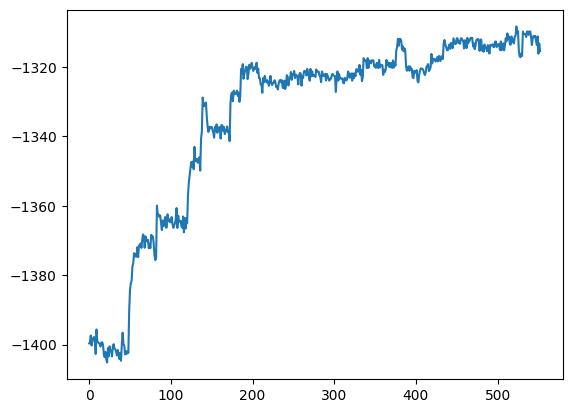

In [961]:
plt.plot(complete_likelihoods)

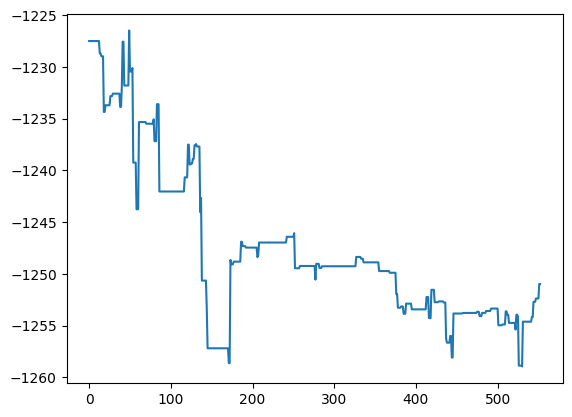

In [959]:
plt.plot(incomplete_likelihoods)

## Old sampler

In [19]:
from lymixture.em import sample_model_params, get_complete_samples

samples = sample_model_params(mixture, steps = 20)
indices = np.random.choice(len(samples), 50, replace=False)
reduced_set = samples[indices]
complete_samples = get_complete_samples(mixture, reduced_set)

100%|██████████| 20/20 [00:04<00:00,  4.87it/s]


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
